# <font color=#0099CC>**Baseline 2: Trivial (media temporal)**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Modelo simple sin parámetros ni entrenamiento: para cada activo, la predicción del promedio futuro de log-retornos se aproxima por la **media temporal** de los log-retornos en la ventana de entrada. Define un suelo de referencia que cualquier red neuronal debe superar.

Trabaja sobre **log-retornos diarios** — el MAE se reporta en esa escala (≈ 1e-2).

**Salidas generadas**:

- `08_results/tablas/baseline_trivial_resultados.csv`
- `08_results/matrices/heatmap_baseline_trivial_*.png`


## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura la raíz del repositorio (`BASE`), el acceso a Google Drive cuando el cuaderno corre en Colab, y se inserta `01_src_compartido` en `sys.path` para importar las utilidades compartidas sin duplicar código.


In [1]:
# ── Detección automática de entorno ─────────────────────────────────────────
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    # En local: ruta a la carpeta raíz del proyecto clonada/descargada
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX
> SRC     : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Se cargan NumPy, Pandas y Matplotlib; se importan `load_data`, `create_dataset`, `get_partitions` desde `dataset_utils` y se asigna `metrics_utils.BASE_DRIVE = BASE` antes de usar funciones que escriben resultados bajo `08_results/`.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from IPython.display import clear_output

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import plot_heatmap, guardar_resultados

## <font color=#0099CC>**3. DESCARGA DE DATOS**</font>

### <font color=#336699>**3.1. Log-retornos diarios de los 23 activos**</font>

Se obtiene la matriz `(T, 23)` de **log-retornos diarios** mediante `load_data`, usando la lista `TICKERS` literal del fichero del profesor. El default `use_log_returns=True` ya devuelve log-retornos (escala que exige el enunciado), por lo que no hace falta pasarlo explícitamente.


In [3]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

> Datos : 16,197 días × 23 activos
> Rango : 1962-01-03 → 2026-05-12


## <font color=#0099CC>**4. PREDICTOR TRIVIAL**</font>

### <font color=#336699>**4.1. Media temporal de la ventana de entrada**</font>

La función reduce cada tensor `X` de forma `(N, v_in, Ch)` a predicciones `(N, Ch)` mediante la media en el eje temporal de entrada — **cero parámetros entrenables**.


In [4]:
def predict_trivial(X):
    """
    Predictor trivial: promedio temporal de la ventana de entrada.
    X: (N, v_in, Ch) → Y_pred: (N, Ch)
    """
    return X.mean(axis=1)

## <font color=#0099CC>**5. EVALUACIÓN 4×4**</font>

### <font color=#336699>**5.1. Combinaciones de ventanas de entrada y salida**</font>

Se recorre la rejilla V_in, V_out \in \{5,10,30,90\}: para cada par se construye (X, Y), se aplica la **partición aleatoria 90/10 con semilla 42** (más un train/val interno) y se calcula MAE en train, val y test.


In [5]:
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida  = [1, 5, 30, 90]
combos     = list(product(ventanas_entrada, ventanas_salida))
resultados = []

N, BAR_LEN = len(combos), 30

for k, (v_in, v_out) in enumerate(combos, 1):
    filled = int(BAR_LEN * k / N)
    bar    = '█' * filled + '░' * (BAR_LEN - filled)
    clear_output(wait=True)
    print(f'> Evaluación 4x4  [{bar}]  {k:>2}/{N}  '
          f'(V_in={v_in:>2}, V_out={v_out:>2})')

    X, Y = create_dataset(data, v_in, v_out)
    X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y)

    mae_train = float(np.mean(np.abs(predict_trivial(X_tr)   - Y_tr)))
    mae_val   = float(np.mean(np.abs(predict_trivial(X_val)  - Y_val)))
    mae_test  = float(np.mean(np.abs(predict_trivial(X_test) - Y_test)))

    resultados.append({
        'modelo':   'trivial',
        'v_in':     v_in,
        'v_out':    v_out,
        'n_params': 0,
        'mae_train': mae_train,
        'mae_val':   mae_val,
        'mae_test':  mae_test,
    })

clear_output(wait=True)
print(f'> Evaluación 4x4 completada  [{"█" * BAR_LEN}]  {N}/{N}')
pd.DataFrame(resultados).round(4)

> Evaluación 4x4 completada  [██████████████████████████████]  16/16


,modelo,v_in,v_out,n_params,mae_train,mae_val,mae_test
0,trivial,5,1,0,0.0130,0.0131,0.0132
1,trivial,5,5,0,0.0078,0.0079,0.0080
2,trivial,5,30,0,0.0059,0.0058,0.0059
3,trivial,5,90,0,0.0055,0.0054,0.0056
4,trivial,10,1,0,0.0123,0.0126,0.0125
5,trivial,10,5,0,0.0067,0.0068,0.0068
6,trivial,10,30,0,0.0044,0.0045,0.0044
7,trivial,10,90,0,0.0040,0.0041,0.0040
8,trivial,30,1,0,0.0119,0.0118,0.0119
9,trivial,30,5,0,0.0059,0.0058,0.0059


## <font color=#0099CC>**6. PERSISTENCIA DE RESULTADOS**</font>

### <font color=#336699>**6.1. Exportación CSV estándar**</font>

Se guarda un fichero con columnas `modelo`, `v_in`, `v_out`, `n_params`, `mae_train`, `mae_val`, `mae_test`, compatible con el resto de modelos del repositorio y con las tablas del informe.


In [6]:
df_resultados = guardar_resultados(resultados, 'baseline_trivial')
print('> Resultados guardados : 08_results/tablas/baseline_trivial_resultados.csv')

> Resultados guardados : 08_results/tablas/baseline_trivial_resultados.csv


## <font color=#0099CC>**7. MAPAS DE CALOR (MAE)**</font>

### <font color=#336699>**7.1. Heatmaps por partición**</font>

Se generan matrices 4×4 para **train**, **val** y **test**, comparables con el resto de arquitecturas del taller.


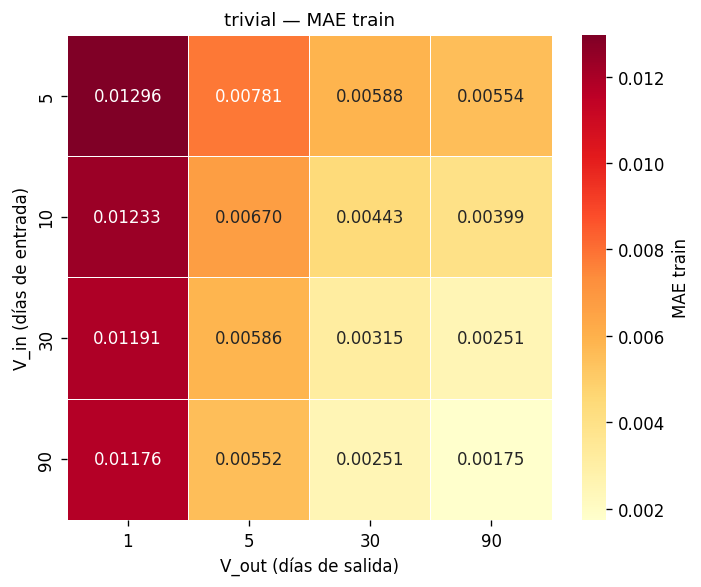

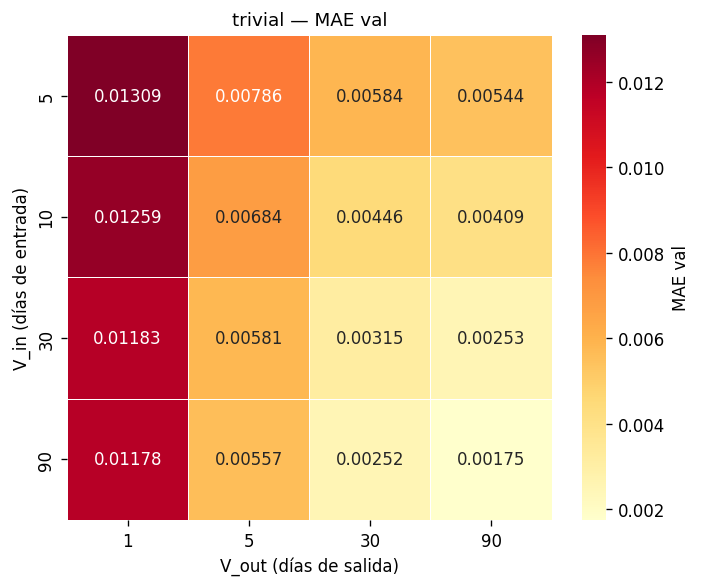

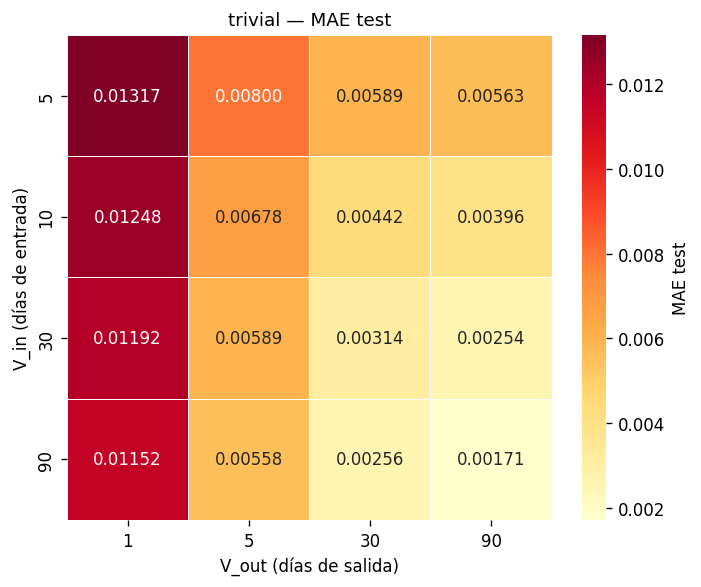

train                             val                          \
v_out             1       5       30      90      1       5       30      90   
V_in \ V_out                                                                   
5             0.0130  0.0078  0.0059  0.0055  0.0131  0.0079  0.0058  0.0054   
10            0.0123  0.0067  0.0044  0.0040  0.0126  0.0068  0.0045  0.0041   
30            0.0119  0.0059  0.0032  0.0025  0.0118  0.0058  0.0031  0.0025   
90            0.0118  0.0055  0.0025  0.0017  0.0118  0.0056  0.0025  0.0017   

                test                          
v_out             1       5       30      90  
V_in \ V_out                                  
5             0.0132  0.0080  0.0059  0.0056  
10            0.0125  0.0068  0.0044  0.0040  
30            0.0119  0.0059  0.0031  0.0025  
90            0.0115  0.0056  0.0026  0.0017

In [7]:
for split in ['train', 'val', 'test']:
    plot_heatmap(df_resultados, 'trivial', split=split, save=True)
    plt.show()

heatmap_df = pd.concat(
    {split: df_resultados.pivot(index='v_in', columns='v_out',
                                values=f'mae_{split}')
     for split in ['train', 'val', 'test']},
    axis=1,
).round(4)
heatmap_df.index.name = 'V_in \\ V_out'
heatmap_df

## <font color=#0099CC>**8. TABLA RESUMEN**</font>

### <font color=#336699>**8.1. MAE en test — referencia cruzada**</font>

Vista pivote V_in \times V_out del MAE en test (escala log-retornos diarios) del baseline trivial. Sirve como referencia inmediata para comprobar si modelos más complejos reducen el error absoluto medio.


In [8]:
print('> MAE Test: Baseline Trivial (escala log-retornos)')
pivot = (df_resultados
         .pivot(index='v_in', columns='v_out', values='mae_test')
         .round(4))
pivot.index.name   = 'V_in \\ V_out'
pivot.columns.name = None
pivot

> MAE Test: Baseline Trivial (escala log-retornos)


,1,5,30,90
V_in \ V_out,,,,
5,0.0132,0.0080,0.0059,0.0056
10,0.0125,0.0068,0.0044,0.0040
30,0.0119,0.0059,0.0031,0.0025
90,0.0115,0.0056,0.0026,0.0017


## <font color=#0099CC>**9. EVALUACIÓN INVESTIGACIÓN (frac-diff + split temporal)**</font>

Sección paralela a la 5: replica el bucle 4×4 sobre los **mismos inputs que usan los notebooks de `07_investigacion_ldp/`** — frac-diff de `log(precio)` con `d = D_FRAC_INV = 0.40` (FFD, López de Prado 2018) y partición temporal con embargo `V_in + V_out` (Purged Split, LdP cap. 7) vía `get_partitions_temporal`. **No** se aplica scaler (el predictor depende de la escala de X y Y; ambos quedan en frac-diff).

> El MAE resultante está en **unidades de frac-diff**, no en log-retornos. Es internamente coherente con el de los modelos de investigación pero **no comparable** en valor absoluto con la sección 5. Se guarda en un CSV separado (`baseline_trivial_inv_resultados.csv`) que los notebooks 07 consultan automáticamente (`metrics_utils.cargar_baselines_combo(..., scope="inv")`).

### <font color=#336699>**9.1. Carga de datos frac-diff**</font>

`load_data(d_frac=D_FRAC_INV, verbose=True)` aplica FFD sobre `log(precio)` y descarta las primeras `L-1` filas del histórico (truncación del kernel).

In [ ]:
from dataset_utils import D_FRAC_INV, get_partitions_temporal

data_inv, df_inv = load_data(d_frac=D_FRAC_INV, verbose=True)
print(f'> Datos (inv) : {data_inv.shape[0]:,} días × {data_inv.shape[1]} activos  '
      f'(escala: frac-diff, d={D_FRAC_INV})')
print(f'> Rango       : {df_inv.index[0].date()} → {df_inv.index[-1].date()}')

### <font color=#336699>**9.2. Evaluación 4×4 con split temporal y embargo**</font>

Mismo recorrido `V_in × V_out` que en la sección 5, pero usando `get_partitions_temporal(X, Y, v_in=v_in, v_out=v_out)` — embargo automático `V_in + V_out` entre train / val / test.

In [ ]:
resultados_inv = []
N, BAR_LEN = len(combos), 30

for k, (v_in, v_out) in enumerate(combos, 1):
    filled = int(BAR_LEN * k / N)
    bar    = '█' * filled + '░' * (BAR_LEN - filled)
    clear_output(wait=True)
    print(f'> Evaluación 4x4 (inv: frac-diff + temporal)  [{bar}]  {k:>2}/{N}  '
          f'(V_in={v_in:>2}, V_out={v_out:>2})')

    X, Y = create_dataset(data_inv, v_in, v_out)
    X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions_temporal(
        X, Y, v_in=v_in, v_out=v_out,
    )

    mae_train = float(np.mean(np.abs(predict_trivial(X_tr)   - Y_tr)))
    mae_val   = float(np.mean(np.abs(predict_trivial(X_val)  - Y_val)))
    mae_test  = float(np.mean(np.abs(predict_trivial(X_test) - Y_test)))
    n_params  = 0

    resultados_inv.append({
        'modelo':    'trivial',
        'v_in':      v_in,
        'v_out':     v_out,
        'n_params':  n_params,
        'mae_train': mae_train,
        'mae_val':   mae_val,
        'mae_test':  mae_test,
    })

clear_output(wait=True)
print(f'> Evaluación 4x4 (inv) completada  [{"█" * BAR_LEN}]  {N}/{N}')
pd.DataFrame(resultados_inv).round(5)

### <font color=#336699>**9.3. Persistencia en CSV separado**</font>

CSV con sufijo `_inv` (`baseline_trivial_inv_resultados.csv`) — esquema idéntico al de la sección 6. Lo recogen automáticamente los notebooks `07_investigacion_ldp/` vía `metrics_utils.cargar_baselines_combo(..., scope="inv")`, que dispatcha por `nombre_modelo.startswith("inv_")`.

In [ ]:
df_resultados_inv = guardar_resultados(resultados_inv, 'baseline_trivial_inv')
print('> Resultados (inv) guardados : 08_results/tablas/baseline_trivial_inv_resultados.csv')

### <font color=#336699>**9.4. Tabla resumen MAE test (escala frac-diff)**</font>

Pivote `V_in × V_out` del MAE en test en la nueva escala. Sirve de referencia directa para los modelos `inv_*` del taller.

In [ ]:
print('> MAE Test: Baseline Trivial (escala frac-diff, split temporal)')
pivot_inv = (df_resultados_inv
             .pivot(index='v_in', columns='v_out', values='mae_test')
             .round(5))
pivot_inv.index.name   = 'V_in \\ V_out'
pivot_inv.columns.name = None
pivot_inv